## Estudio paramétrico de Qubit + cavidad en el THz
Sea un qubit acoplado a dos cavidades:
1. Una de ellas con frecuencia en el óptico. Acoplo muy débil que permite hallar su espectro de emisión
2. Otra con frecuencia en el régimen THz

### El objetivo es estudiar el efecto del acoplo entre el qubit y THz en el espectro de emisión.

El objetivo de este script es investigar cómo los diferentes parámetros afectan al esquema de los picos en el mapa del espectro. Por ejemplo, antes de estar en el regimen de disipative phsyics, solo veiamos picos apreciables en la sideband izquierda, mientras que al haber ajustado los parámetros ahora encontramos picos en ambas, y parecen igual de grandes.

Idea de trabajo es: fijando un valor cualquiera de w_b, vamos a ir seleccionando un parámetro y dandole varios valores.Para cada parametro 1 plot con varias subfiguras, cada una de ellas es el mapa en ese valor concreto.

Parámetros a estudiar son:
- $\gamma$: ahora tenemos $\gamma=0.0001\kappa_{THz}$ y antes eran comparables. 
- $\kappa_a$: disipación en el sensor
- $\chi$: constante de acoplo qubit-cavidad THz

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy.signal import find_peaks

Parámetros y operadores

In [11]:
kappa_b = 1 #decay en la cav de THz
kappa_a_ref = 1 # decay en el sensor (debe ser pequeño, pero mayor que g) A VARIAR
gamma_ref = 1e-4 * kappa_b # decay en el qubit  A VARIAR

g = 0.001       # acoplo qubit con optico
chi_ref =  0.1*kappa_b      # acoplo qubit con THz A VARIAR

w_b = 200*kappa_b

Omega = 200 * kappa_b  # en uds de kappa_b y 1e6 veces mayor que gamma

Na = 2        # truncación de la primera cavidad 
Nb = 3         # segunda cavidad

# Operadores en el espacio producto tensorial
sx = tensor( sigmax(), qeye(Na), qeye(Nb))
sp = tensor( sigmap(), qeye(Na), qeye(Nb))
sm = tensor( sigmam(), qeye(Na), qeye(Nb))
sz = tensor( sigmaz(), qeye(Na), qeye(Nb))

a = tensor( qeye(2), destroy(Na) , qeye(Nb))
a_plus = a.dag()

b = tensor( qeye(2), qeye(Na), destroy(Nb))
b_plus = b.dag()

# Disipadores CUIDADO PORQUE ESTOS VAN A CAMBIAR
Dissipators_ref = []

Dissipators_ref.append(np.sqrt(gamma_ref) * sm)
Dissipators_ref.append(np.sqrt(kappa_a_ref) * a)
Dissipators_ref.append(np.sqrt(kappa_b) * b)



Preparamos el barrido en valores de $\Delta$

In [8]:
npoints = 60

# eje horizontal (frecuencia espectral)
Delta_a_list = np.linspace(-3*Omega, 3*Omega, npoints)

# eje vertical (detuning del qubit)
Delta_q_list = np.linspace(-2*Omega, 2*Omega, npoints)



Hamiltoniano: $$H = \frac{\Omega}{2}\sigma_x + \omega_{THz}b^\dagger b+ \Delta_a a^\dagger a +\Delta_q\sigma_z + g(a^\dagger\sigma_- + a\sigma_+) + \chi(\sigma_z+1)(a + a^\dagger)$$

Cuando la cavidad está muy debilmente acoplada, podemos calcular el espectro como $$S(\omega)\ \alpha\ \braket{a^\dagger a}^{SS}$$.


Donde $$\braket{a^\dagger a}^{SS} = Tr(\rho_{SS}a^\dagger a)$$

## 1. Variando $\gamma$

Parámetros:
Antes $\gamma$ = $\kappa_b$ y ahora es 10.000 veces menor, así que nos fijamos en ese intervalo.

In [32]:
kappa_a = kappa_a_ref
chi = chi_ref

gamma_list = np.linspace(1,10000,4)  * gamma_ref # es decir: gamma={1e-4, 1e-3,1e-2,1e-1}*kappa_THz
print(gamma_list)


[1.000e-04 3.334e-01 6.667e-01 1.000e+00]


Calcular $S(\omega)$  y $\log S(\omega)$ con $\Delta_q$ y $\Delta_a$.

In [33]:
# Diccionario para guardar todos los mapas por valor de w_b
all_S_maps = {}

# Doble bucle
for idx, gamma in enumerate(gamma_list):

    S_map = np.zeros((len(Delta_q_list), len(Delta_a_list)))
    
    Dissipators_gamma = [
        np.sqrt(kappa_b)*b,
        np.sqrt(kappa_a_ref)*a,
        np.sqrt(gamma)*sm
    ]
    for i, Delta_q in enumerate(Delta_q_list):
        
        for j, Delta_a in enumerate(Delta_a_list):
            
        # Hamiltoniano
            H = (Omega/2) * sx \
            + Delta_a * a_plus * a + Delta_q * sz \
            + w_b * b_plus * b \
            + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(b_plus + b)

            rho_SS = steadystate(H, Dissipators_gamma)
            
            S_map[i, j] = expect(a_plus*a, rho_SS)

    # Guardar el mapa
    all_S_maps[gamma] = S_map

### Gráficas mapa y log 

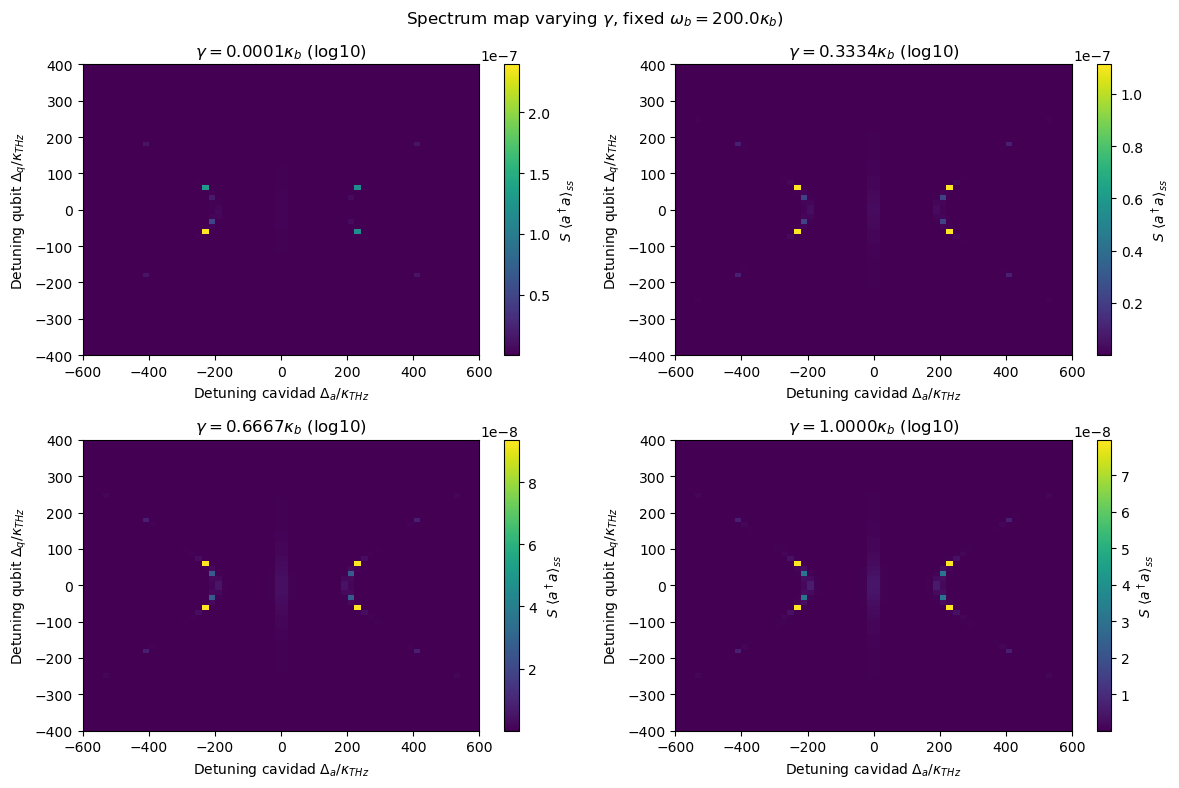

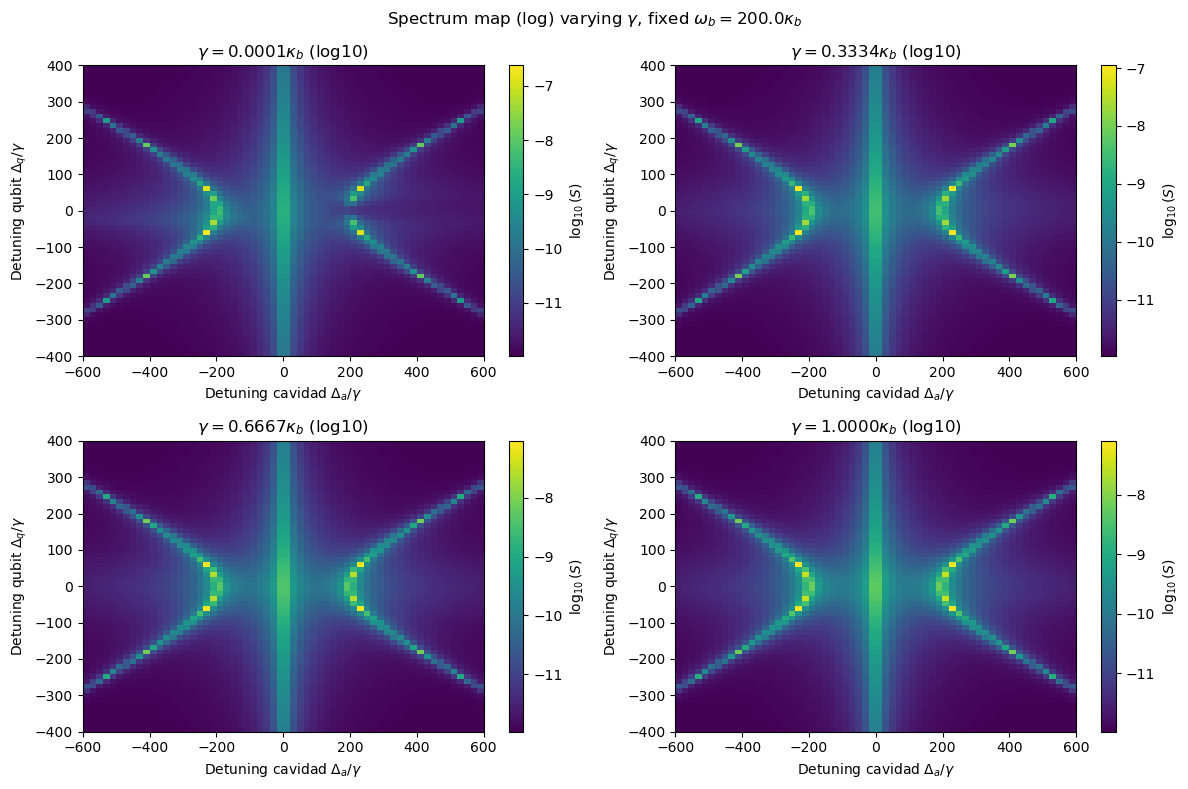

In [34]:
# Crear figuras y ejes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

fig_log, axes_log = plt.subplots(2, 2, figsize=(12, 8))
axes_log = axes_log.flatten()

for idx, gamma in enumerate(gamma_list):

    S_map = all_S_maps[gamma]   # Recuperar mapa ya calculado
    ax = axes[idx]
    ax_log = axes_log[idx]

    # ------------------------
    # Mapa normal
    # ------------------------
    im = ax.imshow(
        S_map,
        extent=[Delta_a_list[0], Delta_a_list[-1],
                Delta_q_list[0], Delta_q_list[-1]],
        aspect='auto',
        origin='lower'
    )

    #ax.axvline(x=-w_b, linestyle='--', color='white', linewidth=1.5)
    #ax.axhline(y=-Delta_q, linestyle='--', color='red', linewidth=1.5)
    ax.set_xlabel(r"Detuning cavidad $\Delta_a/\kappa_{THz}$")
    ax.set_ylabel(r"Detuning qubit $\Delta_q/\kappa_{THz}$")
    ax.set_title(rf"$\gamma = {gamma/kappa_b:.4f}\kappa_b$ (log10)")
    fig.colorbar(im, ax=ax, label=r"$S\ \langle a^\dagger a \rangle_{ss}$")

    # --------------------------
    # Mapa logarítmico
    # --------------------------
    S_log = np.log10(S_map + 1e-12)
    im_log = ax_log.imshow(
        S_log,
        extent=[Delta_a_list[0], Delta_a_list[-1],
                Delta_q_list[0], Delta_q_list[-1]],
        aspect='auto',
        origin='lower'
    )

    #ax_log.axvline(x=-w_b, linestyle='--', color='white', linewidth=1.5)
    #ax_log.axhline(y=-Delta_q, linestyle='--', color='red', linewidth=1.5)
    ax_log.set_xlabel("Detuning cavidad $\\Delta_a/\\gamma$")
    ax_log.set_ylabel("Detuning qubit $\\Delta_q/\\gamma$")
    ax_log.set_title(rf"$\gamma = {gamma/kappa_b:.4f}\kappa_b$ (log10)")
    fig_log.colorbar(im_log, ax=ax_log, label=r"$\log_{10}(S)$")

fig.suptitle(rf"Spectrum map varying $\gamma$, fixed $\omega_b = {w_b/kappa_b}\kappa_b$)")
fig_log.suptitle(rf"Spectrum map (log) varying $\gamma$, fixed $\omega_b = {w_b/kappa_b}\kappa_b$")
plt.tight_layout()
fig.tight_layout()
fig_log.tight_layout()
plt.show()

## 2. Variando $\chi$

Parámetros

In [35]:
kappa_a = kappa_a_ref
gamma = gamma_ref

chi_list = np.linspace(0.05,2,4)  * kappa_b # es decir: gamma={1e-4, 1e-3,1e-2,1e-1}*kappa_THz


Calcular $S(\omega)$  y $\log S(\omega)$ con $\Delta_q$ y $\Delta_a$.

In [36]:
# Diccionario para guardar todos los mapas por valor de w_b
all_S_maps = {}

# Doble bucle
for idx, chi in enumerate(chi_list):

    S_map = np.zeros((len(Delta_q_list), len(Delta_a_list)))
    
    Dissipators_chi = [
        np.sqrt(kappa_b)*b,
        np.sqrt(kappa_a)*a,
        np.sqrt(gamma)*sm
    ]
    for i, Delta_q in enumerate(Delta_q_list):
        
        for j, Delta_a in enumerate(Delta_a_list):
            
        # Hamiltoniano
            H = (Omega/2) * sx \
            + Delta_a * a_plus * a + Delta_q * sz \
            + w_b * b_plus * b \
            + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(b_plus + b)

            rho_SS = steadystate(H, Dissipators_chi)
            
            S_map[i, j] = expect(a_plus*a, rho_SS)

    # Guardar el mapa
    all_S_maps[chi] = S_map

### Gráficas mapa y log 

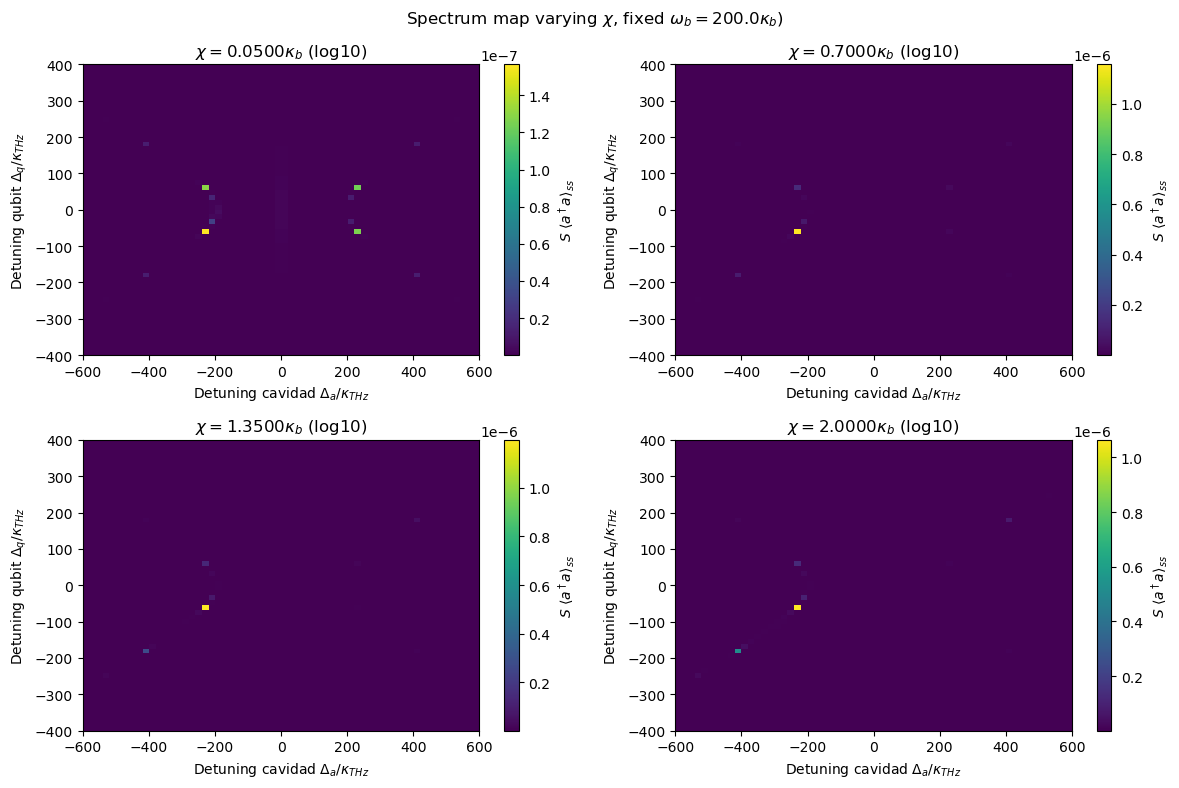

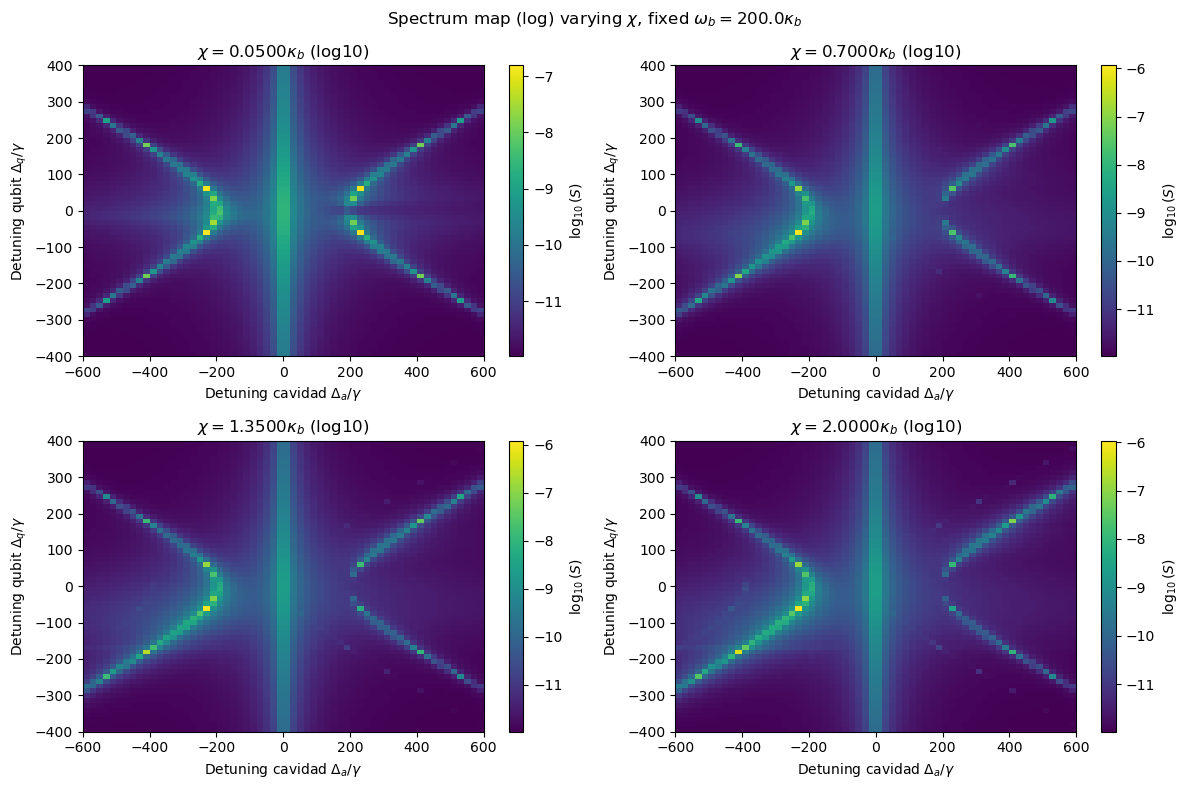

In [37]:
# Crear figuras y ejes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

fig_log, axes_log = plt.subplots(2, 2, figsize=(12, 8))
axes_log = axes_log.flatten()

for idx, chi in enumerate(chi_list):

    S_map = all_S_maps[chi]   # Recuperar mapa ya calculado
    ax = axes[idx]
    ax_log = axes_log[idx]

    # ------------------------
    # Mapa normal
    # ------------------------
    im = ax.imshow(
        S_map,
        extent=[Delta_a_list[0], Delta_a_list[-1],
                Delta_q_list[0], Delta_q_list[-1]],
        aspect='auto',
        origin='lower'
    )

    #ax.axvline(x=-w_b, linestyle='--', color='white', linewidth=1.5)
    #ax.axhline(y=-Delta_q, linestyle='--', color='red', linewidth=1.5)
    ax.set_xlabel(r"Detuning cavidad $\Delta_a/\kappa_{THz}$")
    ax.set_ylabel(r"Detuning qubit $\Delta_q/\kappa_{THz}$")
    ax.set_title(rf"$\chi = {chi/kappa_b:.4f}\kappa_b$ (log10)")
    fig.colorbar(im, ax=ax, label=r"$S\ \langle a^\dagger a \rangle_{ss}$")

    # --------------------------
    # Mapa logarítmico
    # --------------------------
    S_log = np.log10(S_map + 1e-12)
    im_log = ax_log.imshow(
        S_log,
        extent=[Delta_a_list[0], Delta_a_list[-1],
                Delta_q_list[0], Delta_q_list[-1]],
        aspect='auto',
        origin='lower'
    )

    #ax_log.axvline(x=-w_b, linestyle='--', color='white', linewidth=1.5)
    #ax_log.axhline(y=-Delta_q, linestyle='--', color='red', linewidth=1.5)
    ax_log.set_xlabel("Detuning cavidad $\\Delta_a/\\gamma$")
    ax_log.set_ylabel("Detuning qubit $\\Delta_q/\\gamma$")
    ax_log.set_title(rf"$\chi = {chi/kappa_b:.4f}\kappa_b$ (log10)")
    fig_log.colorbar(im_log, ax=ax_log, label=r"$\log_{10}(S)$")

fig.suptitle(rf"Spectrum map varying $\chi$, fixed $\omega_b = {w_b/kappa_b}\kappa_b$)")
fig_log.suptitle(rf"Spectrum map (log) varying $\chi$, fixed $\omega_b = {w_b/kappa_b}\kappa_b$")
plt.tight_layout()
fig.tight_layout()
fig_log.tight_layout()
plt.show()

## 3. Variando $\kappa_a$

Parámetros

In [26]:
chi = chi_ref
gamma = gamma_ref

kappa_a_list = np.array([1, 10, 100, 1000])  * kappa_a_ref # es decir: gamma={1e-4, 1e-3,1e-2,1e-1}*kappa_THz


Calcular $S(\omega)$  y $\log S(\omega)$ con $\Delta_q$ y $\Delta_a$.

In [ ]:
# Diccionario para guardar todos los mapas por valor de w_b
all_S_maps = {}

# Doble bucle
for idx, kappa_a in enumerate(kappa_a_list):

    S_map = np.zeros((len(Delta_q_list), len(Delta_a_list)))
    
    Dissipators_kappa_a = [
        np.sqrt(kappa_b)*b,
        np.sqrt(kappa_a)*a,
        np.sqrt(gamma)*sm
    ]
    for i, Delta_q in enumerate(Delta_q_list):
        
        for j, Delta_a in enumerate(Delta_a_list):
            
        # Hamiltoniano
            H = (Omega/2) * sx \
            + Delta_a * a_plus * a + Delta_q * sz \
            + w_b * b_plus * b \
            + g * (a_plus * sm + a * sp) + chi * (sz+ 1)*(b_plus + b)

            rho_SS = steadystate(H, Dissipators_kappa_a)
            
            S_map[i, j] = expect(a_plus*a, rho_SS)

    # Guardar el mapa
    all_S_maps[kappa_a] = S_map

### Gráficas mapa y log 

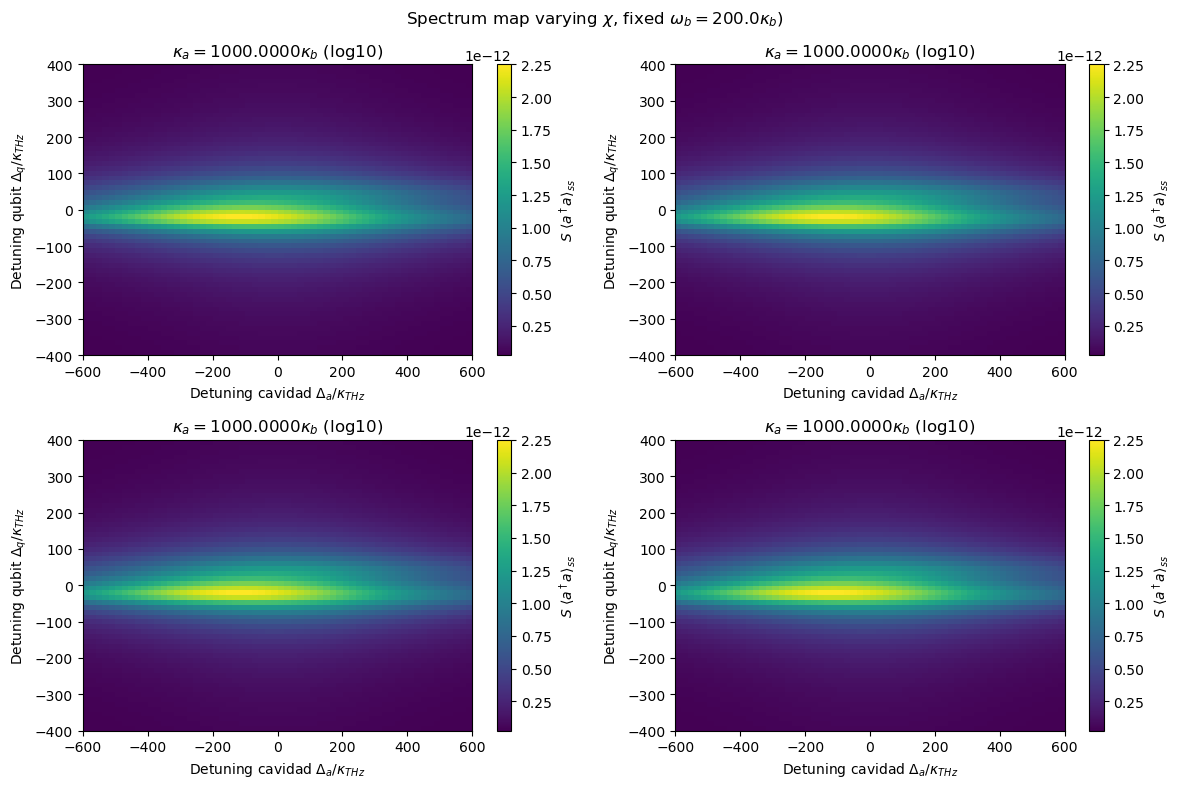

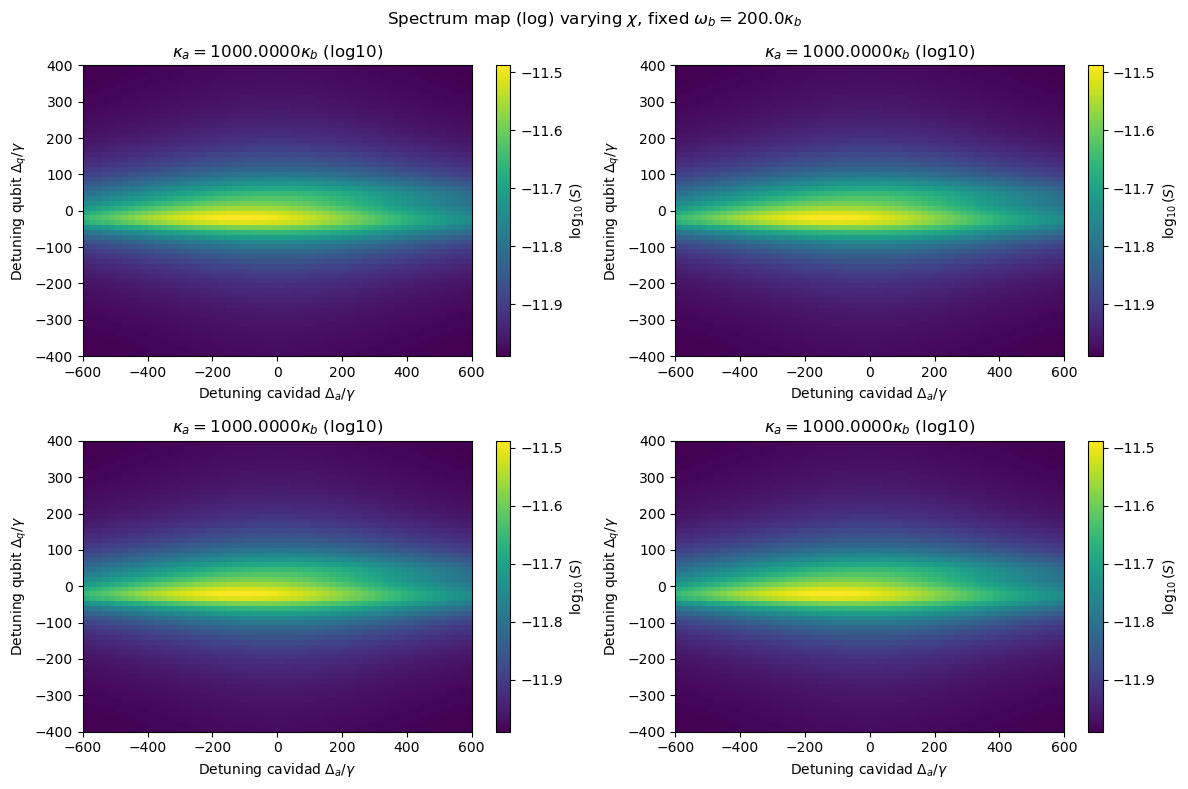

In [29]:
# Crear figuras y ejes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

fig_log, axes_log = plt.subplots(2, 2, figsize=(12, 8))
axes_log = axes_log.flatten()

for idx, chi in enumerate(chi_list):

    S_map = all_S_maps[kappa_a]   # Recuperar mapa ya calculado
    ax = axes[idx]
    ax_log = axes_log[idx]

    # ------------------------
    # Mapa normal
    # ------------------------
    im = ax.imshow(
        S_map,
        extent=[Delta_a_list[0], Delta_a_list[-1],
                Delta_q_list[0], Delta_q_list[-1]],
        aspect='auto',
        origin='lower'
    )

    #ax.axvline(x=-w_b, linestyle='--', color='white', linewidth=1.5)
    #ax.axhline(y=-Delta_q, linestyle='--', color='red', linewidth=1.5)
    ax.set_xlabel(r"Detuning cavidad $\Delta_a/\kappa_{THz}$")
    ax.set_ylabel(r"Detuning qubit $\Delta_q/\kappa_{THz}$")
    ax.set_title(rf"$\kappa_a = {kappa_a/kappa_b:.4f}\kappa_b$ (log10)")
    fig.colorbar(im, ax=ax, label=r"$S\ \langle a^\dagger a \rangle_{ss}$")

    # --------------------------
    # Mapa logarítmico
    # --------------------------
    S_log = np.log10(S_map + 1e-12)
    im_log = ax_log.imshow(
        S_log,
        extent=[Delta_a_list[0], Delta_a_list[-1],
                Delta_q_list[0], Delta_q_list[-1]],
        aspect='auto',
        origin='lower'
    )

    #ax_log.axvline(x=-w_b, linestyle='--', color='white', linewidth=1.5)
    #ax_log.axhline(y=-Delta_q, linestyle='--', color='red', linewidth=1.5)
    ax_log.set_xlabel("Detuning cavidad $\\Delta_a/\\gamma$")
    ax_log.set_ylabel("Detuning qubit $\\Delta_q/\\gamma$")
    ax_log.set_title(rf"$\kappa_a = {kappa_a/kappa_b:.4f}\kappa_b$ (log10)")
    fig_log.colorbar(im_log, ax=ax_log, label=r"$\log_{10}(S)$")

fig.suptitle(rf"Spectrum map varying $\chi$, fixed $\omega_b = {w_b/kappa_b}\kappa_b$)")
fig_log.suptitle(rf"Spectrum map (log) varying $\chi$, fixed $\omega_b = {w_b/kappa_b}\kappa_b$")
plt.tight_layout()
fig.tight_layout()
fig_log.tight_layout()
plt.show()